In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("loan_data.csv")
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Text               24000 non-null  object 
 1   Income             24000 non-null  int64  
 2   Credit_Score       24000 non-null  int64  
 3   Loan_Amount        24000 non-null  int64  
 4   DTI_Ratio          24000 non-null  float64
 5   Employment_Status  24000 non-null  object 
 6   Approval           24000 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 1.3+ MB


Text                 0
Income               0
Credit_Score         0
Loan_Amount          0
DTI_Ratio            0
Employment_Status    0
Approval             0
dtype: int64

#EDA

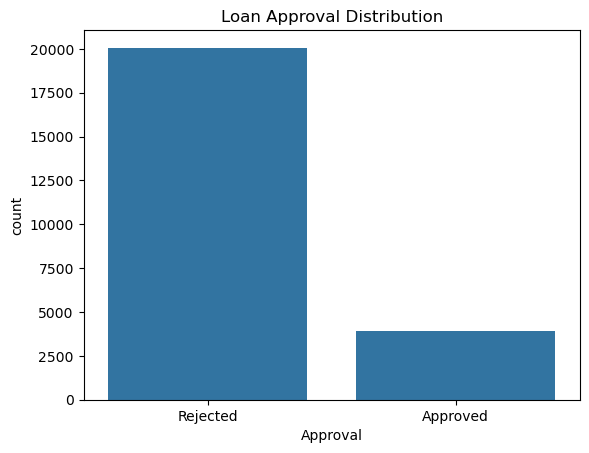

In [3]:
df['Approval'].value_counts()
sns.countplot(x='Approval', data=df)
plt.title("Loan Approval Distribution")
plt.show()


In [4]:
df['Approval'].value_counts(normalize=True)

Approval
Rejected    0.836125
Approved    0.163875
Name: proportion, dtype: float64

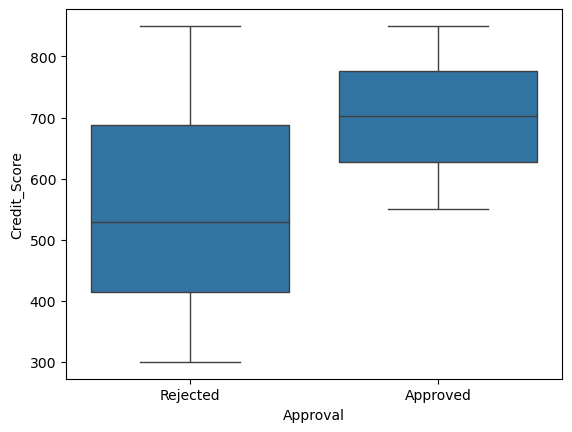

In [5]:
sns.boxplot(x='Approval', y='Credit_Score', data=df)
plt.show()

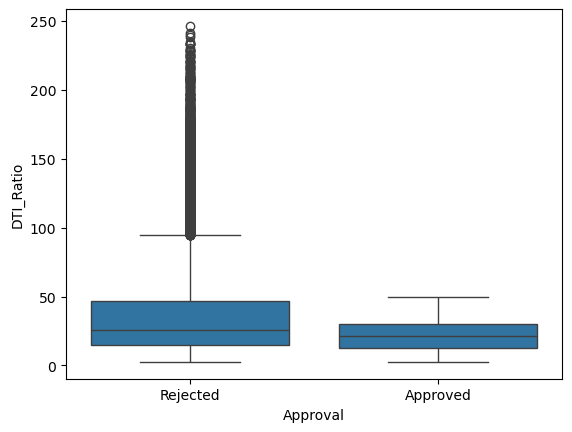

In [6]:
sns.boxplot(x='Approval', y='DTI_Ratio', data=df)
plt.show()

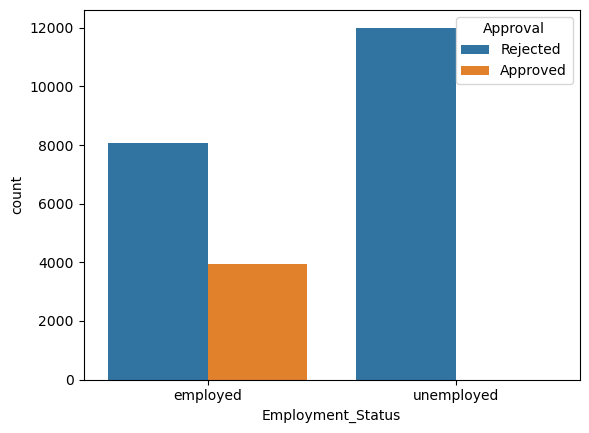

In [7]:
sns.countplot(x='Employment_Status', hue='Approval', data=df)
plt.show()

feature encoding

In [8]:
df = pd.read_csv("loan_data.csv")
df['Employment_Status'] = df['Employment_Status'].str.lower().str.strip()
df['Approval'] = df['Approval'].str.lower().str.strip()

# target encoding
df['Approval'] = df['Approval'].map({'rejected': 0, 'approved': 1})

# employment encoding
df['Employment_Status'] = df['Employment_Status'].map({
    'unemployed': 0,
    'employed': 1
})

# text encoding
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=100)
text_features = tfidf.fit_transform(df['Text'])


In [9]:
df.head()

,Text,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status,Approval
0,I need a loan to pay for an international vaca...,26556,581,8314,79.26,1,0
1,I want to make home improvements like installi...,197392,389,111604,22.14,1,0
2,"I need a loan for home renovation, including a...",44561,523,34118,45.44,1,0
3,I need funds to buy new furniture and applianc...,190363,729,118757,10.22,0,0
4,I need a loan to start a small business.,61853,732,19210,44.13,1,1


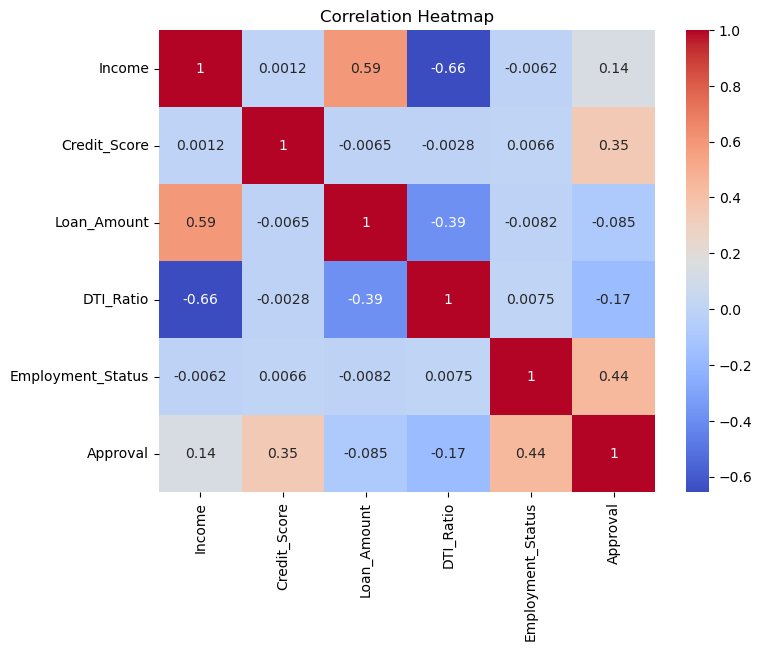

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=100)

text_features = tfidf.fit_transform(df['Text'])

Train-test split & Feature Scaling

In [20]:
from scipy.sparse import hstack

X_numeric = df[
    [
        'Income',
        'Credit_Score',
        'Loan_Amount',
        'DTI_Ratio',
        'Employment_Status'
    ]
]

# combine numeric + tfidf
X = hstack([X_numeric.values, text_features])

# target
y = df['Approval']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)


In [23]:
from sklearn.preprocessing import MaxAbsScaler
scaler = MaxAbsScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Train & Evaluate Models

In [ ]:
#Logistic Regression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,classification_report
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

lr_model.fit(X_train_scaled, y_train)

lr_preds = lr_model.predict(X_test_scaled)

print("Confusion Matrix:\n", confusion_matrix(y_test, lr_preds))
print("Accuracy:", accuracy_score(y_test, lr_preds))
print("Precision:", precision_score(y_test, lr_preds))
print("Recall:", recall_score(y_test, lr_preds))
print("F1-Score:", f1_score(y_test, lr_preds))

Confusion Matrix:
 [[3829  184]
 [ 180  607]]
Accuracy: 0.9241666666666667
Precision: 0.7673830594184576
Recall: 0.7712833545108005
F1-Score: 0.7693282636248415


In [26]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Confusion Matrix:
 [[3885  128]
 [ 108  679]]
Accuracy: 0.9508333333333333
Precision: 0.8413878562577447
Recall: 0.8627700127064803
F1-Score: 0.8519447929736512
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      4013
           1       0.84      0.86      0.85       787

    accuracy                           0.95      4800
   macro avg       0.91      0.92      0.91      4800
weighted avg       0.95      0.95      0.95      4800



In [17]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred = nb_model.predict(X_test_scaled)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))

Confusion Matrix:
 [[2720 1327]
 [   0  753]]
Accuracy: 0.7235416666666666
Precision: 0.36201923076923076
Recall: 1.0
F1-Score: 0.5315919519943523


In [27]:
from sklearn.metrics import roc_auc_score

probs = knn_model.predict_proba(X_test_scaled)[:,1]

auc = roc_auc_score(y_test, probs)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.9795147979992596


In [30]:
import joblib
joblib.dump(
    knn_model,
    "knn_model.pkl"
)
joblib.dump(
    scaler,
    "scaler.pkl"
)
joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

['tfidf_vectorizer.pkl']